In [1]:
from pathlib import Path
import pandas as pd

In [2]:
raw_path = Path("raw")
cleaned_path = Path("cleaned")

In [3]:
df = pd.read_csv(raw_path/"FactTickets_correct.csv")

C:\Users\rodic\AppData\Local\Temp\ipykernel_2680\3272164507.py:1: DtypeWarning: Columns (0: EscalationFlag, 1: CancelledLockedFlag) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(raw_path/"FactTickets_correct.csv")


In [4]:
df.head()

,TicketID,CustomerID,OpenDateTime,FirstTouchDateTime,ResolvedDateTime,ClosedDateTime,LastUpdateDateTime,Status,PriorityID,CategoryID,...,AgentWorkNotes,Tags,ReopenCount,EscalationFlag,EscalationCount,TransferCount,CustomerSatisfaction,ContactReason,SourceSystem,CancelledLockedFlag
0,T000000001,C02296,11/27/2024 14:08,11/27/2024 21:04,12/4/2024 21:44,1/3/2025 21:44,12/4/2024 21:44,Closed,P04,C02,...,Escalated to specialist team after initial tro...,"[""hardware"", ""performance""]",0.0,False,0.0,0.0,NaN,Service Request,Legacy Helpdesk,False
1,T000000002,C01680,3/5/2024 8:10,3/5/2024 9:41,3/10/2024 21:41,4/9/2024 21:41,3/10/2024 21:41,Closed,P04,C03,...,Contacted user for additional details and test...,"[""macos""]",0.0,False,0.0,0.0,4.0,Incident,Legacy Helpdesk,False
2,T000000003,C00357,2/8/2024 10:37,2/8/2024 11:09,2/8/2024 19:33,3/9/2024 19:33,2/8/2024 19:33,Closed,P02,C01,...,Validated symptoms and reproduced where possible.,"[""pwreset""]",0.0,False,0.0,0.0,4.0,Service Request,Legacy Helpdesk,False
3,T000000004,C01622,11/12/2025 10:39,11/12/2025 13:52,11/17/2025 5:39,12/17/2025 5:39,11/17/2025 5:39,Closed,P04,C12,...,Checked logs and configuration; collected diag...,[],0.0,False,0.0,2.0,3.0,Service Request,Legacy Helpdesk,False
4,T000000005,C01085,10/7/2025 11:34,10/7/2025 14:12,10/11/2025 17:59,11/10/2025 17:59,10/11/2025 17:59,Closed,P03,C04,...,Escalated to specialist team after initial tro...,"[""performance"", ""permissions""]",0.0,False,0.0,0.0,NaN,Incident,ServiceNow,False


In [5]:
 initial_shape = df.shape
 initial_shape 

(50009, 29)

## 2.2 Data Cleaning 

### 2.2.1. Eliminare duplicate pe baza unei reguli explicite

In [6]:
### verific randuri unde TicketID apare de mai multe ori 
df[df.duplicated(subset = "TicketID", keep = False)]

,TicketID,CustomerID,OpenDateTime,FirstTouchDateTime,ResolvedDateTime,ClosedDateTime,LastUpdateDateTime,Status,PriorityID,CategoryID,...,AgentWorkNotes,Tags,ReopenCount,EscalationFlag,EscalationCount,TransferCount,CustomerSatisfaction,ContactReason,SourceSystem,CancelledLockedFlag
12941,T000012942,C02274,1/30/2026 15:33,1/30/2026 20:15,2/3/2026 5:51,3/5/2026 5:51,2/3/2026 5:51,Closed,P03,C07,...,Applied remediation and monitored service beha...,"[""escalation""]",0.0,True,1.0,0.0,3.0,Incident,Legacy Helpdesk,False
19488,T000019489,C01211,6/29/2026 9:57,6/29/2026 12:58,6/30/2026 22:34,7/30/2026 22:34,6/30/2026 22:34,Closed,P03,C01,...,Escalated to specialist team after initial tro...,"[""access""]",0.0,False,0.0,1.0,NaN,Incident,Legacy Helpdesk,False
35377,T000035378,C00159,6/8/2025 9:36,6/8/2025 9:56,6/10/2025 9:56,7/10/2025 9:56,6/10/2025 9:56,Closed,P03,C02,...,Contacted user for additional details and test...,"[""macos"", ""permissions""]",0.0,False,0.0,0.0,NaN,Information Request,Legacy Helpdesk,False
35676,T000035677,C01329,7/21/2026 11:39,7/21/2026 12:02,7/22/2026 6:02,NaN,7/22/2026 6:02,Resolved,P02,C08,...,Checked logs and configuration; collected diag...,"[""vip""]",0.0,False,0.0,0.0,NaN,Information Request,Legacy Helpdesk,False
37210,T000037211,C00055,9/10/2025 18:51,9/10/2025 19:01,9/10/2025 23:01,10/10/2025 23:01,9/10/2025 23:01,Closed,P01,C02,...,Contacted user for additional details and test...,"[""hardware""]",0.0,False,0.0,0.0,NaN,Service Request,Legacy Helpdesk,False
50000,T000019489,C01211,6/29/2026 9:57,6/29/2026 12:58,6/30/2026 22:34,7/30/2026 22:34,6/30/2026 22:34,Closed,P03,C01,...,Escalated to specialist team after initial tro...,"[""access""]",0.0,False,0.0,1.0,NaN,Incident,Legacy Helpdesk,False
50001,T000035677,C01329,7/21/2026 11:39,7/21/2026 12:02,7/22/2026 6:02,NaN,7/22/2026 6:02,Resolved,P02,C08,...,Checked logs and configuration; collected diag...,"[""vip""]",0.0,False,0.0,0.0,NaN,Information Request,Legacy Helpdesk,False
50002,T000037211,C00055,9/10/2025 18:51,9/10/2025 19:01,9/10/2025 23:01,10/10/2025 23:01,9/10/2025 23:01,Closed,P01,C02,...,Contacted user for additional details and test...,"[""hardware""]",0.0,False,0.0,0.0,NaN,Service Request,Legacy Helpdesk,False
50003,T000012942,C02274,1/30/2026 15:33,1/30/2026 20:15,2/3/2026 5:51,3/5/2026 5:51,2/3/2026 5:51,Closed,P03,C07,...,Applied remediation and monitored service beha...,"[""escalation""]",0.0,True,1.0,0.0,3.0,Incident,Legacy Helpdesk,False
50004,T000035378,C00159,6/8/2025 9:36,6/8/2025 9:56,6/10/2025 9:56,7/10/2025 9:56,6/10/2025 9:56,Closed,P03,C02,...,Contacted user for additional details and test...,"[""macos"", ""permissions""]",0.0,False,0.0,0.0,NaN,Information Request,Legacy Helpdesk,False


In [7]:
### numar total de  randuri cu duplicate 
df.duplicated(subset = "TicketID" ,keep = False).sum()

np.int64(14)

In [8]:
### cate TicketID care ar tb sa fie distincte  sunt duplicate 

df.loc[df.duplicated(subset ="TicketID" , keep=False), "TicketID"].nunique()

5

In [9]:
### care sunt cele 5 TicketID duplicate 

df.loc[df.duplicated(subset="TicketID",keep=False) , "TicketID"].unique()

<StringArray>
['T000012942', 'T000019489', 'T000035378', 'T000035677', 'T000037211', nan]
Length: 6, dtype: str

### concluzie : 10 randuri afectate , 5 valori duplicate de TicketID 

In [10]:
### creez un data frame doar cu duplicatele si le ordonez dupa TicketID 

duplicates = df[df.duplicated(subset ="TicketID" ,keep =False)].sort_values("TicketID")

duplicates

,TicketID,CustomerID,OpenDateTime,FirstTouchDateTime,ResolvedDateTime,ClosedDateTime,LastUpdateDateTime,Status,PriorityID,CategoryID,...,AgentWorkNotes,Tags,ReopenCount,EscalationFlag,EscalationCount,TransferCount,CustomerSatisfaction,ContactReason,SourceSystem,CancelledLockedFlag
12941,T000012942,C02274,1/30/2026 15:33,1/30/2026 20:15,2/3/2026 5:51,3/5/2026 5:51,2/3/2026 5:51,Closed,P03,C07,...,Applied remediation and monitored service beha...,"[""escalation""]",0.0,True,1.0,0.0,3.0,Incident,Legacy Helpdesk,False
50003,T000012942,C02274,1/30/2026 15:33,1/30/2026 20:15,2/3/2026 5:51,3/5/2026 5:51,2/3/2026 5:51,Closed,P03,C07,...,Applied remediation and monitored service beha...,"[""escalation""]",0.0,True,1.0,0.0,3.0,Incident,Legacy Helpdesk,False
19488,T000019489,C01211,6/29/2026 9:57,6/29/2026 12:58,6/30/2026 22:34,7/30/2026 22:34,6/30/2026 22:34,Closed,P03,C01,...,Escalated to specialist team after initial tro...,"[""access""]",0.0,False,0.0,1.0,NaN,Incident,Legacy Helpdesk,False
50000,T000019489,C01211,6/29/2026 9:57,6/29/2026 12:58,6/30/2026 22:34,7/30/2026 22:34,6/30/2026 22:34,Closed,P03,C01,...,Escalated to specialist team after initial tro...,"[""access""]",0.0,False,0.0,1.0,NaN,Incident,Legacy Helpdesk,False
35377,T000035378,C00159,6/8/2025 9:36,6/8/2025 9:56,6/10/2025 9:56,7/10/2025 9:56,6/10/2025 9:56,Closed,P03,C02,...,Contacted user for additional details and test...,"[""macos"", ""permissions""]",0.0,False,0.0,0.0,NaN,Information Request,Legacy Helpdesk,False
50004,T000035378,C00159,6/8/2025 9:36,6/8/2025 9:56,6/10/2025 9:56,7/10/2025 9:56,6/10/2025 9:56,Closed,P03,C02,...,Contacted user for additional details and test...,"[""macos"", ""permissions""]",0.0,False,0.0,0.0,NaN,Information Request,Legacy Helpdesk,False
35676,T000035677,C01329,7/21/2026 11:39,7/21/2026 12:02,7/22/2026 6:02,NaN,7/22/2026 6:02,Resolved,P02,C08,...,Checked logs and configuration; collected diag...,"[""vip""]",0.0,False,0.0,0.0,NaN,Information Request,Legacy Helpdesk,False
50001,T000035677,C01329,7/21/2026 11:39,7/21/2026 12:02,7/22/2026 6:02,NaN,7/22/2026 6:02,Resolved,P02,C08,...,Checked logs and configuration; collected diag...,"[""vip""]",0.0,False,0.0,0.0,NaN,Information Request,Legacy Helpdesk,False
37210,T000037211,C00055,9/10/2025 18:51,9/10/2025 19:01,9/10/2025 23:01,10/10/2025 23:01,9/10/2025 23:01,Closed,P01,C02,...,Contacted user for additional details and test...,"[""hardware""]",0.0,False,0.0,0.0,NaN,Service Request,Legacy Helpdesk,False
50002,T000037211,C00055,9/10/2025 18:51,9/10/2025 19:01,9/10/2025 23:01,10/10/2025 23:01,9/10/2025 23:01,Closed,P01,C02,...,Contacted user for additional details and test...,"[""hardware""]",0.0,False,0.0,0.0,NaN,Service Request,Legacy Helpdesk,False


In [11]:
### verific daca randurile sunt complet identice pe toate coloanele 

duplicates.duplicated(keep =False).sum()

np.int64(14)

### concluzie : Toate cele 10 randuri implicate in duplicate sunt complet identice pe toate cele 29 coloane . Inseamna ca pot aplica drop_duplicates

     

In [12]:
### aplic drop_duplicates -- stererea duplicatelor 
df = df.drop_duplicates()

In [13]:
shape_final = df.shape
shape_final

(50001, 29)


### 2.2.2 Tratarea valorilor lipsa prin fillna() , inlocuire , pastrare sau eliminare justificata 

In [14]:
## cate valori lipsa am in fiecare coloana 

df.isnull().sum()

TicketID                    1
CustomerID                 21
OpenDateTime                1
FirstTouchDateTime          1
ResolvedDateTime         2456
ClosedDateTime           4019
LastUpdateDateTime          1
Status                      1
PriorityID                  1
CategoryID                  1
SubcategoryID               1
ChannelID                   1
TeamID                      1
AgentID                     1
SLAType                     1
ResolutionCode            192
Resolution                192
RootCauseCategory           1
UserDescription             1
AgentWorkNotes              1
Tags                        1
ReopenCount                 1
EscalationFlag              1
EscalationCount             1
TransferCount               1
CustomerSatisfaction    16448
ContactReason               1
SourceSystem                1
CancelledLockedFlag         1
dtype: int64

In [15]:
 ## creez un data frame doar cu coloanaele care au valori lipsa 
cols_missing = ["CustomerID", "ResolvedDateTime" ,"ClosedDateTime" , "ResolutionCode", "Resolution" , "CustomerSatisfaction"]



In [16]:
## afisare doar acele coloane si numarul valorilor lipsa 

df[cols_missing].isnull().sum()

CustomerID                 21
ResolvedDateTime         2456
ClosedDateTime           4019
ResolutionCode            192
Resolution                192
CustomerSatisfaction    16448
dtype: int64

In [17]:
## salvez rezulatul intr-o variabila 
missing_summary = df[cols_missing].isnull().sum()
missing_summary

CustomerID                 21
ResolvedDateTime         2456
ClosedDateTime           4019
ResolutionCode            192
Resolution                192
CustomerSatisfaction    16448
dtype: int64

In [18]:
## verific daca lipsurile din coloana ResolvedDateTime sunt explicabile prin Status sau sunt suspecte 
df.loc[df["ResolvedDateTime"].isna(), "Status"].value_counts()

Status
Cancelled      2267
In Progress     182
Pending           6
Name: count, dtype: int64

In [19]:
### concluzie : valorile lipsa din coloana ResolvedDateTime sunt justificate prin status  si le pastrez asa stausul este"Cancelled" , "InProgress", "Pending"

In [20]:
## verific daca lipsurile din coloana "ClosedDateTime" sunt justificate prin Status sau sunt suspecte 
df.loc[df["ClosedDateTime"].isna() , "Status"].value_counts()

Status
Cancelled      2267
Resolved       1560
In Progress     183
Pending           6
Reopened          2
Name: count, dtype: int64

In [21]:
### concluzie : valorile lipsa din coloana ClosedDateTime sunt justificate prin status  si le pastrez asa 

In [22]:
## verific daca lipsurile din coloana "Resolution" sunt justificate prin Status sau sunt suspecte ( in Excell sunt 191 lipsuri)
df.loc[df["Resolution"].isna() , "Status"].value_counts()

Status
In Progress    183
Pending          6
Reopened         2
Name: count, dtype: int64

In [23]:
## verific daca lipsurile din coloana "ResolutionCode"  ( in Excell sunt 191) sunt justificate prin Status sau sunt suspecte 
df.loc[df["ResolutionCode"].isna() , "Status"].value_counts()

Status
In Progress    183
Pending          6
Reopened         2
Name: count, dtype: int64

In [24]:
### concluzie : valorile lipsa din coloanele "Resolution" si "ResolutionCode" sunt justificate prin Status 


In [25]:
## verific daca lipsurile din coloana "CustomerSatisfaction" sunt justificate prin Status sau sunt suspecte 
df.loc[df["CustomerSatisfaction"].isna() , "Status"].value_counts()

Status
Closed         14667
Resolved         871
Cancelled        718
In Progress      183
Pending            6
Reopened           2
Name: count, dtype: int64

In [26]:
### nu cred ca este obligatoriu sa dea un feedback clientul ,si ca urmare chiar daca Statusul este resolved, celule din coloana CustomerSatisfaction is null, restul e normal sa fie nule 



In [27]:
## verific lipsurile din colana CustomerID , afisez exacct cele 20 randuri care nu au valori pe ele in coloana CustomerID
df[df["CustomerID"].isna()]

,TicketID,CustomerID,OpenDateTime,FirstTouchDateTime,ResolvedDateTime,ClosedDateTime,LastUpdateDateTime,Status,PriorityID,CategoryID,...,AgentWorkNotes,Tags,ReopenCount,EscalationFlag,EscalationCount,TransferCount,CustomerSatisfaction,ContactReason,SourceSystem,CancelledLockedFlag
1449,T000001450,NaN,12/2/2025 15:57,12/2/2025 16:07,12/3/2025 2:55,1/2/2026 2:55,12/3/2025 2:55,Closed,P02,C05,...,Checked logs and configuration; collected diag...,[],0.0,False,0.0,0.0,4.0,Security Concern,Email Integration,False
1723,T000001724,NaN,3/17/2025 8:24,3/17/2025 10:35,NaN,NaN,3/17/2025 22:35,Cancelled,P02,C02,...,Escalated to specialist team after initial tro...,"[""driver"", ""vip""]",0.0,False,0.0,0.0,4.0,Service Request,Email Integration,True
4109,T000004110,NaN,4/16/2024 6:25,4/16/2024 14:13,4/28/2024 14:13,5/28/2024 14:13,4/28/2024 14:13,Closed,P04,C10,...,Contacted user for additional details and test...,"[""monitoring""]",0.0,False,0.0,0.0,4.0,Service Request,Email Integration,False
4713,T000004714,NaN,10/2/2025 9:07,10/2/2025 15:31,10/4/2025 20:19,11/3/2025 20:19,10/4/2025 20:19,Closed,P03,C03,...,Checked logs and configuration; collected diag...,"[""macos""]",0.0,False,0.0,0.0,5.0,Service Request,Email Integration,False
6662,T000006663,NaN,7/13/2026 8:01,7/13/2026 10:06,7/15/2026 14:54,NaN,7/15/2026 14:54,Resolved,P03,C03,...,Checked logs and configuration; collected diag...,"[""macos""]",0.0,False,0.0,0.0,5.0,Incident,Email Integration,False
14071,T000014072,NaN,1/2/2024 11:32,1/2/2024 20:56,1/5/2024 20:56,2/4/2024 20:56,1/5/2024 20:56,Closed,P03,C04,...,Applied remediation and monitored service beha...,"[""performance""]",0.0,False,0.0,0.0,5.0,Security Concern,Email Integration,False
19149,T000019150,NaN,11/14/2025 9:29,11/14/2025 10:00,11/17/2025 19:36,12/17/2025 19:36,11/17/2025 19:36,Closed,P03,C07,...,Validated symptoms and reproduced where possible.,"[""escalation""]",0.0,True,1.0,0.0,3.0,Access Request,Email Integration,False
23601,T000023602,NaN,1/22/2025 8:49,1/22/2025 12:43,1/24/2025 7:55,2/23/2025 7:55,1/24/2025 7:55,Closed,P03,C05,...,Applied remediation and monitored service beha...,[],0.0,False,0.0,0.0,4.0,Incident,Email Integration,False
26033,T000026034,NaN,10/6/2025 14:04,10/7/2025 0:07,10/8/2025 14:31,11/7/2025 14:31,10/8/2025 14:31,Closed,P03,C12,...,Validated symptoms and reproduced where possib...,[],0.0,False,0.0,0.0,4.0,Incident,Email Integration,False
32320,T000032321,NaN,5/12/2025 3:30,5/12/2025 4:17,NaN,NaN,5/13/2025 9:05,Cancelled,P03,C11,...,Applied remediation and monitored service beha...,[],0.0,False,0.0,1.0,NaN,Service Request,Email Integration,True


In [28]:
df.columns

Index(['TicketID', 'CustomerID', 'OpenDateTime', 'FirstTouchDateTime',
       'ResolvedDateTime', 'ClosedDateTime', 'LastUpdateDateTime', 'Status',
       'PriorityID', 'CategoryID', 'SubcategoryID', 'ChannelID', 'TeamID',
       'AgentID', 'SLAType', 'ResolutionCode', 'Resolution',
       'RootCauseCategory', 'UserDescription', 'AgentWorkNotes', 'Tags',
       'ReopenCount', 'EscalationFlag', 'EscalationCount', 'TransferCount',
       'CustomerSatisfaction', 'ContactReason', 'SourceSystem',
       'CancelledLockedFlag'],
      dtype='str')

In [29]:
df.loc[df["CustomerID"].isna() , ["TicketID", "CustomerID","Status", "ChannelID", "SourceSystem"]]

,TicketID,CustomerID,Status,ChannelID,SourceSystem
1449,T000001450,NaN,Closed,CH03,Email Integration
1723,T000001724,NaN,Cancelled,CH01,Email Integration
4109,T000004110,NaN,Closed,CH02,Email Integration
4713,T000004714,NaN,Closed,CH02,Email Integration
6662,T000006663,NaN,Resolved,CH02,Email Integration
14071,T000014072,NaN,Closed,CH02,Email Integration
19149,T000019150,NaN,Closed,CH05,Email Integration
23601,T000023602,NaN,Closed,CH02,Email Integration
26033,T000026034,NaN,Closed,CH02,Email Integration
32320,T000032321,NaN,Cancelled,CH04,Email Integration


In [30]:
### concluzie : Valorile lipsa NaN din coloana CustomerID sunt exclusiv pt tichete create prin EmailIntegration . Deoarece clientul nu poate fi 
###             identificat cu certitudine , aceste valori vor fi pastrate ca NaN 

## 2.2.3 Standardizarea valorilor categoriale ( spatii , litere mari, mici , etichete inconsistente ). Coloane categoriale sunt coloanele care contin categorii/ etichete , nu valori numerice pe care are sens sa le aduni sau sa fac media 

In [31]:

df.columns 

Index(['TicketID', 'CustomerID', 'OpenDateTime', 'FirstTouchDateTime',
       'ResolvedDateTime', 'ClosedDateTime', 'LastUpdateDateTime', 'Status',
       'PriorityID', 'CategoryID', 'SubcategoryID', 'ChannelID', 'TeamID',
       'AgentID', 'SLAType', 'ResolutionCode', 'Resolution',
       'RootCauseCategory', 'UserDescription', 'AgentWorkNotes', 'Tags',
       'ReopenCount', 'EscalationFlag', 'EscalationCount', 'TransferCount',
       'CustomerSatisfaction', 'ContactReason', 'SourceSystem',
       'CancelledLockedFlag'],
      dtype='str')

In [32]:
df.dtypes

TicketID                    str
CustomerID                  str
OpenDateTime                str
FirstTouchDateTime          str
ResolvedDateTime            str
ClosedDateTime              str
LastUpdateDateTime          str
Status                      str
PriorityID                  str
CategoryID                  str
SubcategoryID               str
ChannelID                   str
TeamID                      str
AgentID                     str
SLAType                     str
ResolutionCode              str
Resolution                  str
RootCauseCategory           str
UserDescription             str
AgentWorkNotes              str
Tags                        str
ReopenCount             float64
EscalationFlag           object
EscalationCount         float64
TransferCount           float64
CustomerSatisfaction    float64
ContactReason               str
SourceSystem                str
CancelledLockedFlag      object
dtype: object

In [33]:
df["Status"].value_counts()

Status
Closed         45982
Cancelled       2267
Resolved        1560
In Progress      183
Pending            6
Reopened           2
Name: count, dtype: int64

In [34]:
df["PriorityID"].value_counts()

PriorityID
P03    27602
P04    12404
P02     8504
P01     1490
Name: count, dtype: int64

In [35]:
df["CategoryID"].value_counts()

CategoryID
C01    7106
C05    6082
C04    5656
C03    5245
C02    4806
C07    4581
C11    4223
C08    3190
C10    2854
C09    2758
C06    2261
C12    1238
Name: count, dtype: int64

In [36]:
df["SourceSystem"].value_counts()

SourceSystem
ServiceNow           32486
Legacy Helpdesk       9988
Email Integration     5050
Monitoring System     2476
Name: count, dtype: int64

In [37]:
df["TicketID"].value_counts()

TicketID
T000000001    1
T000000002    1
T000000003    1
T000000004    1
T000000005    1
             ..
T000049996    1
T000049997    1
T000049998    1
T000049999    1
T000050000    1
Name: count, Length: 50000, dtype: int64

In [38]:
df["CustomerID"].value_counts()

CustomerID
C01936    36
C01491    35
C00343    35
C01204    34
C00565    34
          ..
C01581     8
C01790     8
C02168     8
C01389     7
C00010     7
Name: count, Length: 2500, dtype: int64

In [39]:
# verific daca toate  celulele care nu se vad (....) au aceeasi forma  cu cele vizibile 
df["CustomerID"].str.match(r"C\d{5}$" , na=False).value_counts()

CustomerID
True     49980
False       21
Name: count, dtype: int64

In [40]:
# concluzie : cele 20 care au False sunt cele cu NaN verificate ca sunt ok anterior

In [41]:
df["SubcategoryID"].value_counts()

SubcategoryID
SC040    4223
SC002    1811
SC004    1788
SC003    1787
SC001    1730
SC018    1586
SC017    1536
SC019    1490
SC020    1470
SC015    1454
SC016    1435
SC014    1399
SC013    1368
SC009    1332
SC012    1328
SC010    1302
SC011    1283
SC008    1218
SC007    1204
SC006    1197
SC005    1187
SC025    1184
SC027    1146
SC028    1143
SC026    1108
SC033     955
SC035     906
SC034     897
SC029     823
SC032     806
SC030     784
SC031     777
SC036     752
SC038     725
SC039     700
SC037     667
SC042     641
SC041     597
SC023     591
SC021     585
SC022     548
SC024     537
Name: count, dtype: int64

In [42]:
df["ChannelID"].value_counts()

ChannelID
CH01    19130
CH02    11978
CH03     8582
CH04     5682
CH05     4628
Name: count, dtype: int64

In [43]:
df["TeamID"].value_counts()

TeamID
T03    10205
T01     9176
T07     9091
T04     6682
T05     6199
T06     2961
T02     2511
T10     1710
T09      752
T08      713
Name: count, dtype: int64

In [44]:
df["AgentID"].value_counts()

AgentID
A003    1717
A013    1709
A053    1705
A023    1695
A043    1690
A033    1689
A001    1564
A011    1561
A017    1545
A057    1541
A051    1538
A041    1534
A007    1532
A037    1520
A027    1512
A031    1507
A021    1472
A047    1441
A054    1135
A044    1130
A004    1126
A024    1103
A014    1096
A034    1092
A025    1066
A005    1060
A015    1054
A035    1010
A055    1008
A045    1001
A016     509
A006     503
A036     502
A026     497
A046     475
A056     475
A052     459
A002     438
A032     411
A042     409
A022     409
A012     385
A020     323
A060     294
A040     292
A050     275
A030     266
A010     260
A058     134
A029     131
A049     130
A059     126
A019     122
A009     122
A039     121
A018     121
A038     116
A048     116
A008     114
A028     112
Name: count, dtype: int64

In [45]:
df["SLAType"].value_counts()

SLAType
Standard    34256
Premium     15695
Critical       49
Name: count, dtype: int64

In [46]:
df["Resolution"].value_counts()

Resolution
Reinstalled/updated affected component; user confirmed normal operation.           7904
Applied workaround and documented permanent-fix recommendation.                    7900
Service restored after configuration correction and validation with user.          7888
Resolved after vendor guidance was applied and validated.                          7836
Root cause isolated and remediation completed; monitoring showed no recurrence.    7750
Access restored; user confirmed successful authentication.                         7693
Reported issue was not confirmed or did not require service-desk remediation.      2267
Issue remediated and resolution validated.                                          571
Name: count, dtype: int64

In [47]:
df["ResolutionCode"].value_counts()

ResolutionCode
Resolved                     10808
Configuration Change          7110
Access Granted                5666
Workaround Provided           5628
User Guidance                 5599
Hardware Replacement          4325
Software Reinstalled          3740
Vendor Fix                    2814
Cancelled / Not Justified     2267
No Fault Found                1852
Name: count, dtype: int64

In [48]:
df["RootCauseCategory"].value_counts()

RootCauseCategory
Configuration             8011
User Error                6612
Software Defect           6063
Network Issue             5418
Hardware Failure          4533
Identity/Access           4417
Security Event            3046
Capacity/Performance      2916
Data Issue                2560
Third-Party/Vendor        2448
Unknown/Not Determined    2011
Process Gap               1965
Name: count, dtype: int64

In [49]:
# in coloana "UserDescription' fiind un text liber , verific daca exista valori lipsa , spatii inutile la inceput,sfarsit, texte complet  goale 
df["UserDescription"].isna().sum()


np.int64(1)

In [50]:
# pt spatii inutile 
df["UserDescription"].str.strip()

0        User reports monitor after since yesterday. Im...
1        Request received from end user: antivirus. Add...
2        User reports mfa after after a recent update. ...
3        User cannot complete normal workflow because o...
4        User cannot complete normal workflow because o...
                               ...                        
49996    Request received from end user: vpn. Additiona...
49997    User reports mfa after after a recent update. ...
49998    User cannot complete normal workflow because o...
49999    Problem started since yesterday; user states t...
50005                                                  NaN
Name: UserDescription, Length: 50001, dtype: str

In [51]:
# daca exista siruri goale 
(df["UserDescription"]=="").sum()

np.int64(0)

In [52]:
# pt coloana "AgentWorkNotes" 
df["AgentWorkNotes"]

0        Escalated to specialist team after initial tro...
1        Contacted user for additional details and test...
2        Validated symptoms and reproduced where possible.
3        Checked logs and configuration; collected diag...
4        Escalated to specialist team after initial tro...
                               ...                        
49996    Checked logs and configuration; collected diag...
49997    Validated symptoms and reproduced where possib...
49998    Checked logs and configuration; collected diag...
49999    Escalated to specialist team after initial tro...
50005                                                  NaN
Name: AgentWorkNotes, Length: 50001, dtype: str

In [53]:
# coloana "Agent WorkNotes" fiind un text liber verific daca exista valori lipsa , spatii inutile la inceput , sfarsit, texte complet goale 
df["AgentWorkNotes"].isna().sum()

np.int64(1)

In [54]:
# pt spatii inutile la inceput/sfarsit  
df["AgentWorkNotes"].str.strip()

0        Escalated to specialist team after initial tro...
1        Contacted user for additional details and test...
2        Validated symptoms and reproduced where possible.
3        Checked logs and configuration; collected diag...
4        Escalated to specialist team after initial tro...
                               ...                        
49996    Checked logs and configuration; collected diag...
49997    Validated symptoms and reproduced where possib...
49998    Checked logs and configuration; collected diag...
49999    Escalated to specialist team after initial tro...
50005                                                  NaN
Name: AgentWorkNotes, Length: 50001, dtype: str

In [55]:
# daca exista siruri goale
(df["AgentWorkNotes"]=="").sum()

np.int64(0)

### concluzie : Coloanele "UserDescription" , "AgentWorkNotes" sunt campuri de text liber. Nu au fost identificate valori lipsa , siruri goale sau probleme evidente de formatare , astfel ca valorile sunt pastrate nemodificate 

### concluzie: Valorile categoriale au fost verificate prin value_counts().Nu au foat gasite etichete inconsistente privind literele mari/mici sau denumirile .

In [56]:
df["Tags"].value_counts()

Tags
[]                               12404
["macos"]                         1829
["windows"]                       1805
["vpn"]                           1417
["performance"]                   1377
                                 ...  
["vip", "mfa", "outage"]             1
["vip", "performance", "ios"]        1
["vip", "bug", "network"]            1
["vip", "driver", "malware"]         1
["vip", "mfa", "database"]           1
Name: count, Length: 1495, dtype: int64

In [57]:
df["Tags"].isna().sum()

np.int64(1)

In [58]:
# elimin spatii la inceput / sfarsit daca exista
df["Tags"] = df["Tags"].str.strip()
df["Tags"]

0           ["hardware", "performance"]
1                             ["macos"]
2                           ["pwreset"]
3                                    []
4        ["performance", "permissions"]
                      ...              
49996                   ["performance"]
49997                           ["mfa"]
49998                                []
49999                   ["performance"]
50005                               NaN
Name: Tags, Length: 50001, dtype: str

In [59]:
# verific cate celule din coloana Tags au spatii inutile la inceput / sfasit . Compar valoarea originala cu valoarea fara spatii exterioare 
df["Tags"] != df["Tags"].str.strip()

0        False
1        False
2        False
3        False
4        False
         ...  
49996    False
49997    False
49998    False
49999    False
50005     True
Name: Tags, Length: 50001, dtype: bool

In [60]:
# numara cate celule  au spatii inutile la incept / sfarsit
(df["Tags"] != df["Tags"].str.strip()).sum()

np.int64(1)

### concluzie : Coloana "Tags " a fost verificata pt patii suplimentare la inceputul si sfarsitul valorilor . Nu au fost identificate probleme , deci nu este necesara nicio modificare .


## 2.2.4 Conversia si validarea tipurilor de date , in special a datelor calendaristice 

In [61]:
# pun toate coloanaele care data calendaristica intr-o lista 
date_cols = ["OpenDateTime","FirstTouchDateTime","ResolvedDateTime","ClosedDateTime","LastUpdateDateTime"]
date_cols

['OpenDateTime',
 'FirstTouchDateTime',
 'ResolvedDateTime',
 'ClosedDateTime',
 'LastUpdateDateTime']

In [62]:
# apoi le convertesc pe toate odata 
for col in date_cols:
    df[col] = pd.to_datetime(df[col] , errors ="coerce")

In [63]:
# verific daca s-a convertit in datetime 
df[date_cols].dtypes

OpenDateTime          datetime64[us]
FirstTouchDateTime    datetime64[us]
ResolvedDateTime      datetime64[us]
ClosedDateTime        datetime64[us]
LastUpdateDateTime    datetime64[us]
dtype: object

In [64]:
# verific daca prin conversie au aparut valori invalide 
df[date_cols].isna().sum()

OpenDateTime             1
FirstTouchDateTime       1
ResolvedDateTime      2456
ClosedDateTime        4019
LastUpdateDateTime       1
dtype: int64

In [65]:
# concluzie : valorile 2455 , 4018 erau legitime inainte de conversie 

## 2.2.5 Verificarea relatiilor Category -Subcategory si a altor combinatii intre chei 

### continui observatia facuta in excell , unde am gasit ca subcategoria SC001 apare in categoria C01 , dar exista si 10 cazuri C10 - SC001 , care par suspecte 


In [66]:
# vreau sa vad toate combinatiile CategoryID  + SubcategoryID si cate randuri are fiecare 
category_subcategory =( df.groupby(["CategoryID" , "SubcategoryID"])
                                           .size()
                                           .reset_index(name="Count"))
category_subcategory

,CategoryID,SubcategoryID,Count
0,C01,SC001,1720
1,C01,SC002,1811
2,C01,SC003,1787
3,C01,SC004,1788
4,C02,SC005,1187
5,C02,SC006,1197
6,C02,SC007,1204
7,C02,SC008,1218
8,C03,SC009,1332
9,C03,SC010,1302


In [67]:
### Subcategoria SC001 apare asociata la doua CategoryID diferite 
df.loc[df["SubcategoryID"] == "SC001" , "CategoryID"].value_counts()


CategoryID
C01    1720
C10      10
Name: count, dtype: int64

In [68]:
# tb sa merg in fisierul DimSubcategory sa vad carei categorii apartine subcategoria SC001 . 

In [69]:
dim_sub = pd.read_csv(raw_path / "DimSubcategory.csv")

In [70]:
dim_sub

,SubcategoryID,SubcategoryName,CategoryID,ComplexityLevel
0,SC001,Password Reset,C01,Low
1,SC002,MFA,C01,Medium
2,SC003,Account Locked,C01,Low
3,SC004,Permission Request,C01,Medium
4,SC005,Laptop,C02,Medium
5,SC006,Desktop,C02,Medium
6,SC007,Monitor,C02,Low
7,SC008,Printer,C02,Medium
8,SC009,Operating System,C03,Medium
9,SC010,Office Software,C03,Medium


In [71]:
dim_sub[dim_sub["SubcategoryID"] == "SC001"]

,SubcategoryID,SubcategoryName,CategoryID,ComplexityLevel
0,SC001,Password Reset,C01,Low


In [72]:
# identific cele 10 randuri 
df[(df["CategoryID"] == "C10") & (df["SubcategoryID"] == "SC001")] 

,TicketID,CustomerID,OpenDateTime,FirstTouchDateTime,ResolvedDateTime,ClosedDateTime,LastUpdateDateTime,Status,PriorityID,CategoryID,...,AgentWorkNotes,Tags,ReopenCount,EscalationFlag,EscalationCount,TransferCount,CustomerSatisfaction,ContactReason,SourceSystem,CancelledLockedFlag
1103,T000001104,C01252,2025-07-31 12:30:00,2025-07-31 18:44:00,2025-08-13 06:22:00,2025-09-12 06:22:00,2025-08-13 06:22:00,Closed,P04,C10,...,Validated symptoms and reproduced where possib...,"[""email""]",0.0,False,0.0,0.0,4.0,Incident,Legacy Helpdesk,False
7713,T000007714,C00484,2024-06-19 07:32:00,2024-06-19 08:47:00,2024-06-23 23:11:00,2024-07-23 23:11:00,2024-06-23 23:11:00,Closed,P03,C10,...,Compared with known issues and reviewed recent...,"[""escalation"", ""redcode"", ""hardware""]",0.0,True,1.0,0.0,4.0,Incident,Legacy Helpdesk,False
8442,T000008443,C02404,2026-05-28 19:25:00,2026-05-28 21:16:00,2026-05-30 02:04:00,2026-06-29 02:04:00,2026-05-30 02:04:00,Closed,P02,C10,...,Compared with known issues and reviewed recent...,"[""escalation"", ""database""]",0.0,True,1.0,1.0,NaN,Access Request,Legacy Helpdesk,False
17777,T000017778,C00377,2025-10-08 20:22:00,2025-10-09 01:09:00,2025-10-12 01:09:00,2025-11-11 01:09:00,2025-10-12 01:09:00,Closed,P03,C10,...,Applied remediation and monitored service beha...,"[""network""]",0.0,False,0.0,0.0,4.0,Incident,Legacy Helpdesk,False
24184,T000024185,C02399,2024-08-21 08:05:00,2024-08-21 12:02:00,2024-08-24 21:38:00,2024-09-23 21:38:00,2024-08-24 21:38:00,Closed,P03,C10,...,Validated symptoms and reproduced where possible.,[],0.0,False,0.0,0.0,NaN,Incident,Legacy Helpdesk,False
36119,T000036120,C02186,2024-09-23 12:57:00,2024-09-23 17:09:00,2024-09-26 17:09:00,2024-10-26 17:09:00,2024-09-26 17:09:00,Closed,P03,C10,...,Checked logs and configuration; collected diag...,"[""performance""]",0.0,False,0.0,0.0,4.0,Incident,Legacy Helpdesk,False
37778,T000037779,C00846,2025-05-05 12:54:00,2025-05-05 16:50:00,2025-05-11 04:50:00,2025-06-10 04:50:00,2025-05-11 04:50:00,Closed,P04,C10,...,Compared with known issues and reviewed recent...,"[""bug""]",0.0,False,0.0,0.0,NaN,Incident,Legacy Helpdesk,False
38096,T000038097,C02062,2024-07-31 09:48:00,2024-07-31 13:06:00,2024-08-03 22:42:00,2024-09-02 22:42:00,2024-08-03 22:42:00,Closed,P03,C10,...,Escalated to specialist team after initial tro...,"[""escalation"", ""network""]",0.0,True,1.0,0.0,2.0,Service Request,Legacy Helpdesk,False
38431,T000038432,C00328,2025-11-19 11:30:00,2025-11-19 11:44:00,2025-11-19 16:08:00,2025-12-19 16:08:00,2025-11-19 16:08:00,Closed,P01,C10,...,Escalated to specialist team after initial tro...,"[""macos""]",0.0,False,0.0,0.0,5.0,Incident,Legacy Helpdesk,False
45708,T000045709,C01051,2025-02-03 15:36:00,2025-02-03 16:23:00,2025-02-15 16:23:00,2025-03-17 16:23:00,2025-02-15 16:23:00,Closed,P04,C10,...,Applied remediation and monitored service beha...,"[""database""]",0.0,False,0.0,0.0,NaN,Incident,Legacy Helpdesk,False


In [73]:
# aplic regula de corectare in tabela FactTickets adica subcategoria SC001 din categoria C10 sa o trec in categoria C01
df.loc[(df["CategoryID"] == "C10") & (df["SubcategoryID"] == "SC001") , "CategoryID" ] = "C01"

In [74]:
# dupa corectare verific din nou 
df[df["SubcategoryID"] == "SC001"]["CategoryID"].value_counts()

CategoryID
C01    1730
Name: count, dtype: int64

In [75]:
# sau cu df.loc
df.loc[df["SubcategoryID"] == "SC001" , "CategoryID"].value_counts()


CategoryID
C01    1730
Name: count, dtype: int64

## 2.2.6 Identificarea valorilor temporale imposibile si stabilirea unei reguli de tratare 

### refacem in Python verificarile pe care le-am facut in Excell si a caror concluzii sunt in pagina de Excell 'Data Quality': FirstTouchDateTime < OpenDateTime ; ResolvedDateTime < FirstTouchDateTiem ; ClosedDateTime < ResolvedDateTime 

In [76]:
df.columns

Index(['TicketID', 'CustomerID', 'OpenDateTime', 'FirstTouchDateTime',
       'ResolvedDateTime', 'ClosedDateTime', 'LastUpdateDateTime', 'Status',
       'PriorityID', 'CategoryID', 'SubcategoryID', 'ChannelID', 'TeamID',
       'AgentID', 'SLAType', 'ResolutionCode', 'Resolution',
       'RootCauseCategory', 'UserDescription', 'AgentWorkNotes', 'Tags',
       'ReopenCount', 'EscalationFlag', 'EscalationCount', 'TransferCount',
       'CustomerSatisfaction', 'ContactReason', 'SourceSystem',
       'CancelledLockedFlag'],
      dtype='str')

In [77]:
# verificare cate inregistrari sunt FirstTouchDateTime < OpenDateTime 
Error_FirstTouch = df[df["FirstTouchDateTime"] < df["OpenDateTime"]]

In [78]:
Error_FirstTouch.shape[0]

12

In [79]:
# vizualizarea celor 12 erori 
Error_FirstTouch[["TicketID" ,"OpenDateTime" , "FirstTouchDateTime"]]

,TicketID,OpenDateTime,FirstTouchDateTime
3156,T000003157,2025-03-12 09:00:00,2025-03-12 08:30:00
8920,T000008921,2025-06-23 14:32:00,2025-06-23 14:02:00
13155,T000013156,2025-02-27 02:59:00,2025-02-27 02:29:00
14883,T000014884,2024-11-07 09:14:00,2024-11-07 08:44:00
18060,T000018061,2026-02-05 16:20:00,2026-02-05 15:50:00
18254,T000018255,2025-01-31 15:56:00,2025-01-31 15:26:00
20872,T000020873,2024-12-25 10:46:00,2024-12-25 10:16:00
29534,T000029535,2026-02-04 12:43:00,2026-02-04 12:13:00
31733,T000031734,2026-05-04 07:07:00,2026-05-04 06:37:00
43676,T000043677,2024-11-04 14:26:00,2024-11-04 13:56:00


In [80]:
# verificare cate inregistrari sunt ResolvedDateTime < FirstTouchDateTime 
error_resolved = df[df["ResolvedDateTime"].notna() & (df["ResolvedDateTime"]< df["FirstTouchDateTime"])]
error_resolved.shape[0]

0

In [81]:
# verificare cate inregistrari sunt ClosedDateTime < ResolvedDateTime 
error_closed = df[df["ClosedDateTime"].notna() 
            & df["ResolvedDateTime"].notna()
            & (df["ClosedDateTime"] < df["ResolvedDateTime"])]
error_closed.shape[0]

0

## 2.3 Validarea rezultatului  

### 2.3.1

In [82]:
# shape initial 
initial_shape

(50009, 29)

In [83]:
# shape final 
shape_final 

(50001, 29)

In [84]:
print("Shape initial:", initial_shape)

Shape initial: (50009, 29)


In [85]:
print("Shape final:" , shape_final)

Shape final: (50001, 29)


In [86]:
# numar randuri eliminate 
print("Randuri eliminate:" , initial_shape[0] -shape_final[0])

Randuri eliminate: 8


### 2.3.2 

In [87]:
## (1) verific ca nu mai exista TicketID duplicate 
df.duplicated(subset = ["TicketID"]).sum()

np.int64(0)

In [88]:
## (2) un raport isna().sum() pt coloanele verificate in Excell
df[cols_missing].isna().sum()

CustomerID                 21
ResolvedDateTime         2456
ClosedDateTime           4019
ResolutionCode            192
Resolution                192
CustomerSatisfaction    16448
dtype: int64

In [89]:
## coloanele verificate in Excell
cols_excel_check = ["AgentID" , "FirstTouchDateTime", "ResolvedDateTime", "ClosedDateTime","Resolution" ,"RootCauseCategory","CustomerSatisfaction"]
df[cols_excel_check].isna().sum()

AgentID                     1
FirstTouchDateTime          1
ResolvedDateTime         2456
ClosedDateTime           4019
Resolution                192
RootCauseCategory           1
CustomerSatisfaction    16448
dtype: int64

### concluzie subpunct(2) Valorile lipsa ramase au fost analizate anterior si sunt documentate prin status sau prin natura campului. Nu au fost completate artificial valorile pt care nu exista o regula sigura de imputare .

In [90]:
## (3) numarul incalcarilor pt fiecare regula temporala definita la etapa Excel


In [91]:
ceck_1 = (df["FirstTouchDateTime"] < df["OpenDateTime"]).sum()
ceck_1

np.int64(12)

In [92]:
ceck_2 = (df["ResolvedDateTime"].notna() & (df["ResolvedDateTime"]< df["FirstTouchDateTime"])).sum()
ceck_2

np.int64(0)

In [93]:
ceck_3 = (df["ClosedDateTime"].notna() 
            & df["ResolvedDateTime"].notna()
            & (df["ClosedDateTime"] < df["ResolvedDateTime"])).sum()
ceck_3

np.int64(0)

In [94]:
print("FirstTouchDateTime" <"OpenDateTime:" ,ceck_1)
print( "ResolvedDateTime" < "FirstTouchDateTime:", ceck_2)
print ( "ClosedDateTime" < "ResolvedDateTime:" , ceck_3)

True 12
False 0
True 0


### concluzie supct(3) : au ramas 12 incalcari ale regulii FTDT < ODT . Acestea au fost pastrate intentionat deoarece nu exista suficiente informatii pt corectare. 

In [95]:
## (4) valori distincte pt 'Status' dupa standardizare .

df["Status"].unique()

<StringArray>
['Closed', 'Cancelled', 'Resolved', 'In Progress', 'Pending', 'Reopened', nan]
Length: 7, dtype: str

### concluzie subpc(3) : nu exista valori duplicate pt coloana 'Status' determinate de litere mari/mici sau spatii suplimentare 

### 2.3.3  Construiti si afisati doua verificari agregate pe datele curatate:

In [96]:
## (1) pd.pivot_table cu numarul de TicketID pe Status 
pivot_status = pd.pivot_table ( df,
                                index = "Status" ,
                                values = "TicketID" ,
                                aggfunc ="count")
pivot_status


,TicketID
Status,
Cancelled,2267
Closed,45982
In Progress,183
Pending,6
Reopened,2
Resolved,1560


In [97]:
## pivotul pivot_status confirma distribuirea finala a celor 50.000 de tichete dupa curaterea duplicatelor

In [98]:
## (2) pd.pivot_table cu numarul de TicketID pe CategoryID si PriorityID 
pivot_categoryID_priorityID = pd.pivot_table ( df,
                                           index = "CategoryID",
                                           columns ="PriorityID",
                                           values = "TicketID" ,
                                           aggfunc = "count")
pivot_categoryID_priorityID
                                           

PriorityID,P01,P02,P03,P04
CategoryID,,,,
C01,189,1168,3864,1895
C02,162,831,2674,1139
C03,137,884,2993,1231
C04,153,988,3098,1417
C05,207,1014,3384,1477
C06,69,372,1229,591
C07,144,786,2577,1074
C08,100,512,1782,796
C09,84,485,1495,694


In [99]:
## pivotul CategoryID_PriorityID confirma ca datele curate pot fi agregate pe cele doua dimensiuni .

### Generati 2 grafice : distributia tichtelor pe Status si evolutia lunara a tichetelor dupa OpenDateTime 


In [100]:
import matplotlib.pyplot as plt

### 1. grafic distributia tichetelor pe Status

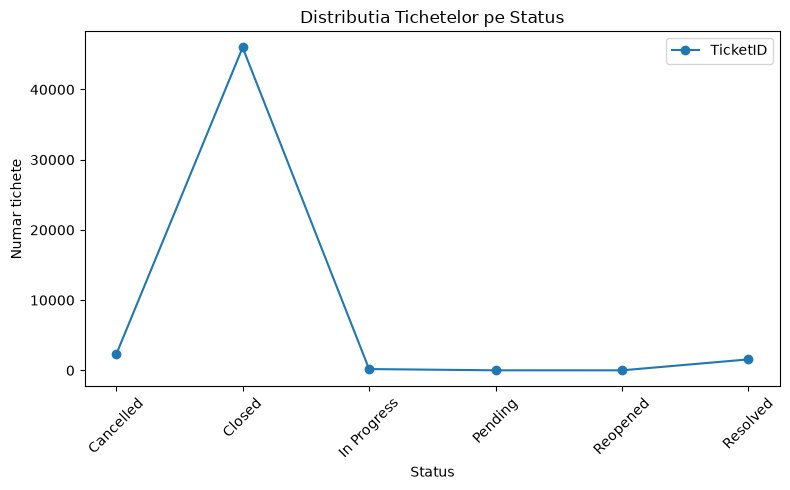

In [101]:
pivot_status.plot (figsize = (8,5) ,
                   kind="line",
                   marker = "o"
                  )
plt.title ( "Distributia Tichetelor pe Status")
plt.xlabel ( "Status")
plt.ylabel ( " Numar tichete ")
plt.xticks (rotation =45)
plt.tight_layout()
plt.show()

### 2. grafic evolutia lunara a tichetelor dupa OpenDateTime 


In [102]:
df.columns

Index(['TicketID', 'CustomerID', 'OpenDateTime', 'FirstTouchDateTime',
       'ResolvedDateTime', 'ClosedDateTime', 'LastUpdateDateTime', 'Status',
       'PriorityID', 'CategoryID', 'SubcategoryID', 'ChannelID', 'TeamID',
       'AgentID', 'SLAType', 'ResolutionCode', 'Resolution',
       'RootCauseCategory', 'UserDescription', 'AgentWorkNotes', 'Tags',
       'ReopenCount', 'EscalationFlag', 'EscalationCount', 'TransferCount',
       'CustomerSatisfaction', 'ContactReason', 'SourceSystem',
       'CancelledLockedFlag'],
      dtype='str')

In [103]:
df.head()

,TicketID,CustomerID,OpenDateTime,FirstTouchDateTime,ResolvedDateTime,ClosedDateTime,LastUpdateDateTime,Status,PriorityID,CategoryID,...,AgentWorkNotes,Tags,ReopenCount,EscalationFlag,EscalationCount,TransferCount,CustomerSatisfaction,ContactReason,SourceSystem,CancelledLockedFlag
0,T000000001,C02296,2024-11-27 14:08:00,2024-11-27 21:04:00,2024-12-04 21:44:00,2025-01-03 21:44:00,2024-12-04 21:44:00,Closed,P04,C02,...,Escalated to specialist team after initial tro...,"[""hardware"", ""performance""]",0.0,False,0.0,0.0,NaN,Service Request,Legacy Helpdesk,False
1,T000000002,C01680,2024-03-05 08:10:00,2024-03-05 09:41:00,2024-03-10 21:41:00,2024-04-09 21:41:00,2024-03-10 21:41:00,Closed,P04,C03,...,Contacted user for additional details and test...,"[""macos""]",0.0,False,0.0,0.0,4.0,Incident,Legacy Helpdesk,False
2,T000000003,C00357,2024-02-08 10:37:00,2024-02-08 11:09:00,2024-02-08 19:33:00,2024-03-09 19:33:00,2024-02-08 19:33:00,Closed,P02,C01,...,Validated symptoms and reproduced where possible.,"[""pwreset""]",0.0,False,0.0,0.0,4.0,Service Request,Legacy Helpdesk,False
3,T000000004,C01622,2025-11-12 10:39:00,2025-11-12 13:52:00,2025-11-17 05:39:00,2025-12-17 05:39:00,2025-11-17 05:39:00,Closed,P04,C12,...,Checked logs and configuration; collected diag...,[],0.0,False,0.0,2.0,3.0,Service Request,Legacy Helpdesk,False
4,T000000005,C01085,2025-10-07 11:34:00,2025-10-07 14:12:00,2025-10-11 17:59:00,2025-11-10 17:59:00,2025-10-11 17:59:00,Closed,P03,C04,...,Escalated to specialist team after initial tro...,"[""performance"", ""permissions""]",0.0,False,0.0,0.0,NaN,Incident,ServiceNow,False


In [104]:
## grupez dupa   luna tichetele  

tickets_monthly = df.groupby (df["OpenDateTime"].dt.to_period("M")) ["TicketID"].count()

tickets_monthly

OpenDateTime
2024-01    1714
2024-02    1376
2024-03    1466
2024-04    1485
2024-05    1527
2024-06    1310
2024-07    1337
2024-08    1482
2024-09    1619
2024-10    1655
2024-11    1356
2024-12    1309
2025-01    1899
2025-02    1437
2025-03    1635
2025-04    1613
2025-05    1669
2025-06    1479
2025-07    1543
2025-08    1589
2025-09    1891
2025-10    1895
2025-11    1469
2025-12    1622
2026-01    1951
2026-02    1653
2026-03    1743
2026-04    1731
2026-05    1629
2026-06    1746
2026-07    1659
2026-08     511
Freq: M, Name: TicketID, dtype: int64

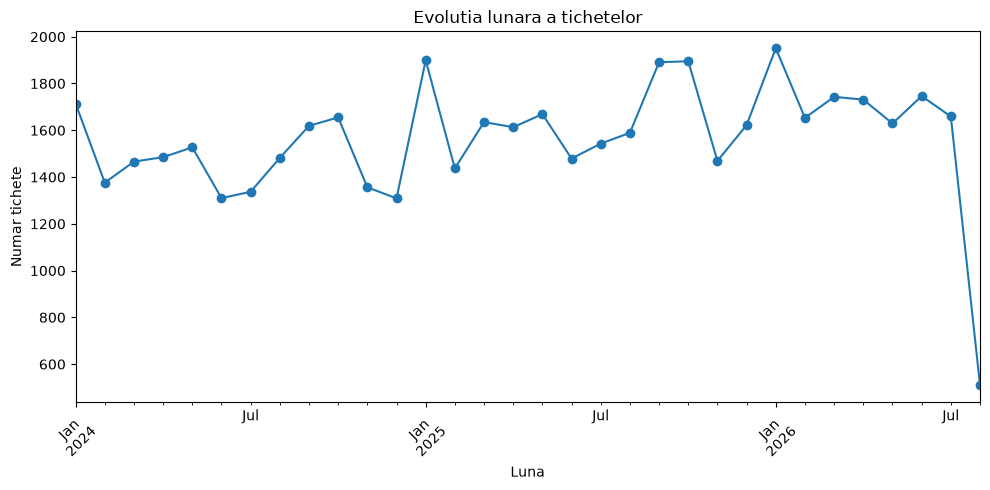

In [105]:
## graficul 
tickets_monthly.plot ( figsize = (10,5),
                       kind = "line",
                       marker ="o" )
plt.title ("Evolutia lunara a tichetelor")
plt.xlabel (" Luna ")
plt.ylabel ( "Numar tichete")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()           
           

## 2.4 Exportul datelor curate 

### 2.4.1 Exportati tabela FactTickets curatata intr-un fisier CVS nou , fara a suprascrie sursa originala ;   2.4.2 Pastrati denumirea FactTickets pentru fisierul rezulat , astfel incat acesta sa poata inlocui sursa FactTickets in etapa SQL ; 2.4.3 Fisierul FactTickets rezultat trebuie sa poata inlocui functional fisierul FactTickets original in etapele urmatoare 

In [106]:
df.info()

<class 'pandas.DataFrame'>
Index: 50001 entries, 0 to 50005
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   TicketID              50000 non-null  str           
 1   CustomerID            49980 non-null  str           
 2   OpenDateTime          50000 non-null  datetime64[us]
 3   FirstTouchDateTime    50000 non-null  datetime64[us]
 4   ResolvedDateTime      47545 non-null  datetime64[us]
 5   ClosedDateTime        45982 non-null  datetime64[us]
 6   LastUpdateDateTime    50000 non-null  datetime64[us]
 7   Status                50000 non-null  str           
 8   PriorityID            50000 non-null  str           
 9   CategoryID            50000 non-null  str           
 10  SubcategoryID         50000 non-null  str           
 11  ChannelID             50000 non-null  str           
 12  TeamID                50000 non-null  str           
 13  AgentID               50000 non-

In [107]:
df["EscalationFlag"].value_counts(dropna=False)

EscalationFlag
False    46190
True      3810
NaN          1
Name: count, dtype: int64

In [108]:
df["CancelledLockedFlag"].value_counts(dropna=False)

CancelledLockedFlag
False    47790
True      2210
NaN          1
Name: count, dtype: int64

In [109]:
# creaza calea catre folderul 'cleaned ' si salveaza DataFrame -ul 
output_file = cleaned_path / "FactTickets.csv"
df.to_csv(output_file , index = False)


In [110]:
df["EscalationFlag"].apply(type).value_counts()

EscalationFlag
<class 'bool'>     50000
<class 'float'>        1
Name: count, dtype: int64

In [111]:
df["CancelledLockedFlag"].apply(type).value_counts()

CancelledLockedFlag
<class 'bool'>     50000
<class 'float'>        1
Name: count, dtype: int64

In [112]:
print(len(df))
print(len(df["EscalationFlag"]))
print(df["EscalationFlag"].isna().sum())

50001
50001
1


In [113]:
df.tail()

,TicketID,CustomerID,OpenDateTime,FirstTouchDateTime,ResolvedDateTime,ClosedDateTime,LastUpdateDateTime,Status,PriorityID,CategoryID,...,AgentWorkNotes,Tags,ReopenCount,EscalationFlag,EscalationCount,TransferCount,CustomerSatisfaction,ContactReason,SourceSystem,CancelledLockedFlag
49996,T000049997,C00813,2024-09-05 07:12:00,2024-09-05 10:25:00,2024-09-12 22:25:00,2024-10-12 22:25:00,2024-09-12 22:25:00,Closed,P04,C04,...,Checked logs and configuration; collected diag...,"[""performance""]",0.0,False,0.0,0.0,5.0,Incident,ServiceNow,False
49997,T000049998,C00255,2026-04-23 00:10:00,2026-04-23 00:56:00,2026-04-23 09:20:00,2026-05-23 09:20:00,2026-04-23 09:20:00,Closed,P02,C01,...,Validated symptoms and reproduced where possib...,"[""mfa""]",0.0,False,0.0,1.0,NaN,Incident,ServiceNow,False
49998,T000049999,C02119,2024-04-25 04:16:00,2024-04-25 06:06:00,2024-04-28 15:42:00,2024-05-28 15:42:00,2024-04-28 15:42:00,Closed,P03,C07,...,Checked logs and configuration; collected diag...,[],0.0,False,0.0,0.0,4.0,Incident,Legacy Helpdesk,False
49999,T000050000,C00776,2025-05-15 04:00:00,2025-05-15 12:41:00,2025-05-23 00:41:00,2025-06-22 00:41:00,2025-05-23 00:41:00,Closed,P04,C04,...,Escalated to specialist team after initial tro...,"[""performance""]",0.0,False,0.0,1.0,3.0,Incident,Legacy Helpdesk,False
50005,NaN,NaN,NaT,NaT,NaT,NaT,NaT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [114]:
## verific daca este tot randul gol 
df[df["TicketID"].isna()]

,TicketID,CustomerID,OpenDateTime,FirstTouchDateTime,ResolvedDateTime,ClosedDateTime,LastUpdateDateTime,Status,PriorityID,CategoryID,...,AgentWorkNotes,Tags,ReopenCount,EscalationFlag,EscalationCount,TransferCount,CustomerSatisfaction,ContactReason,SourceSystem,CancelledLockedFlag
50005,NaN,NaN,NaT,NaT,NaT,NaT,NaT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [115]:
## elimin randul complet gol inainte de export si verific cu print(df.shape)
df = df.dropna(subset=["TicketID"]).reset_index(drop=True)

In [116]:
print(df.shape)

(50000, 29)


In [117]:
df.tail()

,TicketID,CustomerID,OpenDateTime,FirstTouchDateTime,ResolvedDateTime,ClosedDateTime,LastUpdateDateTime,Status,PriorityID,CategoryID,...,AgentWorkNotes,Tags,ReopenCount,EscalationFlag,EscalationCount,TransferCount,CustomerSatisfaction,ContactReason,SourceSystem,CancelledLockedFlag
49995,T000049996,C02471,2025-01-22 14:12:00,2025-01-22 15:08:00,2025-01-25 08:13:00,2025-02-24 08:13:00,2025-01-25 08:13:00,Closed,P03,C09,...,Contacted user for additional details and test...,"[""android""]",0.0,False,0.0,0.0,4.0,Incident,ServiceNow,False
49996,T000049997,C00813,2024-09-05 07:12:00,2024-09-05 10:25:00,2024-09-12 22:25:00,2024-10-12 22:25:00,2024-09-12 22:25:00,Closed,P04,C04,...,Checked logs and configuration; collected diag...,"[""performance""]",0.0,False,0.0,0.0,5.0,Incident,ServiceNow,False
49997,T000049998,C00255,2026-04-23 00:10:00,2026-04-23 00:56:00,2026-04-23 09:20:00,2026-05-23 09:20:00,2026-04-23 09:20:00,Closed,P02,C01,...,Validated symptoms and reproduced where possib...,"[""mfa""]",0.0,False,0.0,1.0,NaN,Incident,ServiceNow,False
49998,T000049999,C02119,2024-04-25 04:16:00,2024-04-25 06:06:00,2024-04-28 15:42:00,2024-05-28 15:42:00,2024-04-28 15:42:00,Closed,P03,C07,...,Checked logs and configuration; collected diag...,[],0.0,False,0.0,0.0,4.0,Incident,Legacy Helpdesk,False
49999,T000050000,C00776,2025-05-15 04:00:00,2025-05-15 12:41:00,2025-05-23 00:41:00,2025-06-22 00:41:00,2025-05-23 00:41:00,Closed,P04,C04,...,Escalated to specialist team after initial tro...,"[""performance""]",0.0,False,0.0,1.0,3.0,Incident,Legacy Helpdesk,False


In [118]:
print(df["EscalationFlag"].isna().sum())
print(df["CancelledLockedFlag"].isna().sum())

0
0


In [119]:
output_file .exists()

True

In [120]:
## exportul datelor curate 
output_file = cleaned_path / "FactTickets.csv"
df.to_csv(output_file,index = False)

In [121]:
# citire fisier 'FactTickets' rezultat 
df_ceck = pd.read_csv(output_file)

In [122]:
## recitire fisier exportat 
df_ceck.shape

(50000, 29)